In [6]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q shap

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                              ConfusionMatrixDisplay)

PROCESSED_PATH = '/content/drive/MyDrive/Churn_Hackathon/data/processed/'

X_train = pd.read_csv(PROCESSED_PATH + 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_PATH + 'X_test.csv')
y_test  = pd.read_csv(PROCESSED_PATH + 'y_test.csv').squeeze()

with open(PROCESSED_PATH + 'best_model.pkl', 'rb') as f:
    model = pickle.load(f)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("✅ Model and data loaded")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model and data loaded


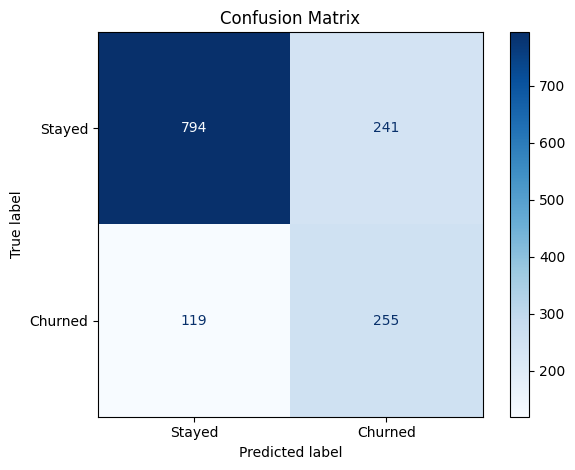

In [7]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(PROCESSED_PATH + '../confusion_matrix.png', dpi=150)
plt.show()

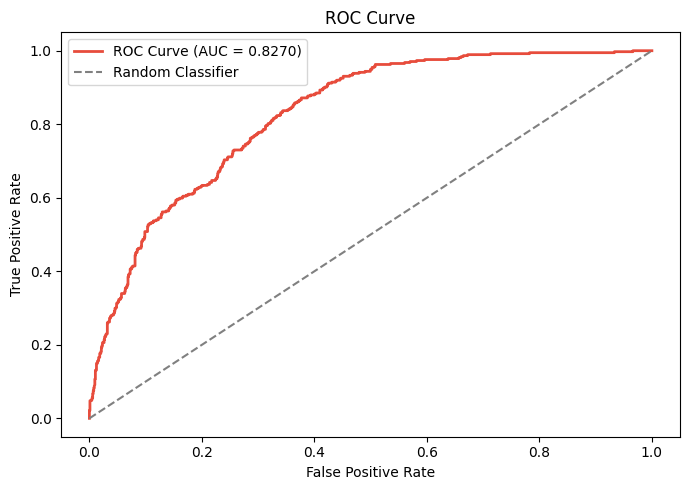

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig(PROCESSED_PATH + '../roc_curve.png', dpi=150)
plt.show()

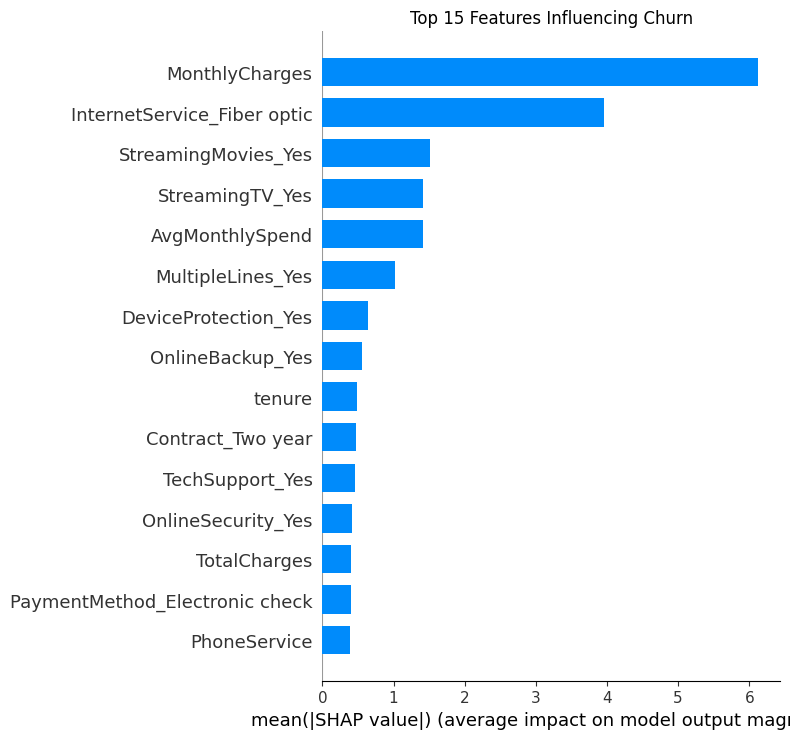

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

# Auto-detect model type and use correct SHAP explainer
if isinstance(model, (RandomForestClassifier, XGBClassifier)):
    # Tree-based models → TreeExplainer (fast)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

else:
    # Linear models like Logistic Regression → LinearExplainer
    explainer = shap.LinearExplainer(model, X_train)
    shap_values = explainer.shap_values(X_test)
    sv = shap_values

# Plot feature importance
plt.figure()
shap.summary_plot(sv, X_test, plot_type='bar',
                  max_display=15, show=False)
plt.title('Top 15 Features Influencing Churn')
plt.tight_layout()
plt.savefig(PROCESSED_PATH + '../feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

=== Customer Risk Distribution ===
Risk_Category
Low Risk       671
High Risk      388
Medium Risk    350
Name: count, dtype: int64


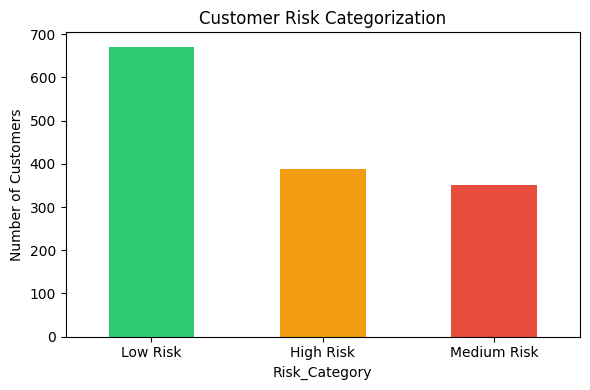

✅ Predictions saved!


In [10]:
# Categorize each customer into risk groups based on churn probability
def categorize_risk(prob):
    if prob < 0.3:
        return 'Low Risk'
    elif prob < 0.6:
        return 'Medium Risk'
    else:
        return 'High Risk'

results_df = X_test.copy()
results_df['Churn_Probability'] = y_prob
results_df['Churn_Prediction']  = ['Yes' if p == 1 else 'No' for p in y_pred]
results_df['Risk_Category']     = y_prob.apply(lambda p: categorize_risk(p)) \
                                   if hasattr(y_prob, 'apply') \
                                   else pd.Series(y_prob).apply(categorize_risk).values

# Show risk distribution
risk_counts = pd.Series(results_df['Risk_Category']).value_counts()
print("=== Customer Risk Distribution ===")
print(risk_counts)

# Save predictions file
results_df[['Churn_Probability', 'Churn_Prediction', 'Risk_Category']].to_csv(
    PROCESSED_PATH + 'predictions.csv', index=False
)

plt.figure(figsize=(6, 4))
risk_counts.plot(kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Customer Risk Categorization')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PROCESSED_PATH + '../risk_categorization.png', dpi=150)
plt.show()

print("✅ Predictions saved!")